# Can shared vocabulary fix consensus blind spots? (T8 evaluation demo)

This notebook is a small, runnable demo of the **T8 evaluation** (iteration 4) from a study of *gold-free* metrics for
natural-language → first-order-logic (NL→FOL) output quality.

**Background.** A candidate FOL formalization is scored by **consensus with its peers**: other systems' formalizations of the same
sentence. The baseline rule **END_MAJ** accepts a candidate when most peers agree with it (z3-checked equivalence after
predicate alignment). Two error rates describe any such rule:

* **e**: the share of **ERROR** candidates that are still endorsed (false acceptance).
* **d**: the share of **CORRECT** candidates that are *not* endorsed (false rejection). This is the consensus *blind spot*.

The full run found END_MAJ at **e = 0.124, d = 0.537**. More than half of the correct formalizations get rejected. T8 asks whether
**shared vocabulary** could close that gap: if all systems used the same predicate names, how many rejected CORRECT candidates would their peers
then agree with? Every candidate–peer pair is put in one class: `EXACT`, `NAME_ONLY` (differs only in spelling), `ALIGN_ONLY`,
`VOCAB` (differs only in vocabulary choice), or `IRREDUCIBLE`. Several **counting rules** then give a predicted d:

| rule | a peer counts as agreeing when … |
|---|---|
| `R_exact` | exactly equivalent (no alignment) |
| `R_align` | equivalent after alignment (= END_MAJ) |
| `R_name` | `R_align` ∪ NAME_ONLY |
| `R_point_label` | `R_name` + VOCAB pairs accepted with a label-aware probability (the pre-registered **d_floor** prediction) |
| `R_liberal` | `R_name` ∪ every VOCAB pair |
| `R_oracle` | the peer has the same gold label (no-anchoring oracle floor) |

A candidate is endorsed when **more than half** of its peers agree. Results are given for the **9-family** peer pool and for the matched
**3-family pool** (deepseek / microsoft / openai; PRIMARY).

**What this demo runs.** The original `eval.py` is a thin orchestrator. It runs 13 CPU-only scripts in order (prereg → R_COMP z3 matrix →
Part 1 → Part 3 → Part 2 → Part 4 → figures → audit → `eval_out.json`). Those scripts need the read-only workspaces of earlier
experiments and several minutes of z3 calls. So the notebook (1) keeps the orchestrator code, printing its execution plan
instead of spawning the scripts, and (2) re-runs the **Part-1 summary step** on real per-row outputs: e/d per counting rule with
the original `ed_ci` / sentence-cluster bootstrap code, the peer-pair class shares, and the `c_vres` AUROC. It uses a
100-row subset of the 2,672 scorable rows, stratified by stratum × gold label, and compares the result with the full-run numbers.

## Setup
Install dependencies. `loguru` is not preinstalled on Colab. The core scientific packages are installed at Colab's pinned versions only when running outside Colab.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0')

Imports: the original `eval.py` import block, followed by the libraries that the Part-1 summary code and the plots use.

In [2]:
# --- original eval.py imports ---
from __future__ import annotations

import argparse
import os
import subprocess
import sys
import time
from pathlib import Path

from loguru import logger

# --- additional imports for the in-notebook Part-1 summary + plots ---
import json
import numpy as np
import pandas as pd
from scipy.stats import rankdata
import matplotlib.pyplot as plt

Data-loading helper. It reads `mini_demo_data.json` from GitHub and falls back to a local copy.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_StxQVNnY7aQW/round-4/evaluation-3/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["demo_subset"])
print("datasets:", [(d["dataset"], len(d["examples"])) for d in data["datasets"]])
print("full-run reference metrics:", len(data["reference_metrics_full_run"]))

100 rows from dataset E_R_AB_consensus_scorable (full run: 2,672 rows). Stratified by stratum x gold label in proportion to the full data (min 3 per cell), at most one row per sentence within a cell, seed 0; rows interleaved so any prefix stays balanced. Endorsements are the full-run per-row outputs (computed against each candidate's complete peer set).
datasets: [('E_R_AB_consensus_scorable', 100)]
full-run reference metrics: 157


## Config
Every tunable parameter is set here.

* `N_ROWS`: how many candidate rows of the demo subset to use (rows are interleaved across stratum × label cells, so any prefix stays balanced).
* `B`: sentence-cluster bootstrap replicates for the confidence intervals. **The original uses `B = 2000`.**
* `RUN_SUBPROCESSES`: the original orchestrator runs 13 scripts with `subprocess.run`. Those scripts are not shipped with this demo and need
  the read-only eval-2 / experiment-7 / experiment-8 workspaces, so the notebook keeps this `False` and only prints the plan.

In [5]:
N_ROWS = 100            # rows of the demo subset to analyse (max 100 here; the full run has 2,672)
B = 2000                # sentence-cluster bootstrap replicates (original: B = 2000)
SEED = 0                # bootstrap seed (original: seed=0)
RUN_SUBPROCESSES = False  # original: True (runs src/*.py, needs the external read-only workspaces)
ARGV = []               # command-line args for the orchestrator, e.g. ["--skip-matrix"] or ["--from", "part1"]

POOLS = ("3pool", "9fam")   # matched 3-family pool (PRIMARY) and 9-family pool
RULES = ["R_exact", "R_align", "R_name", "R_point_label", "R_liberal", "R_oracle"]

## The T8 orchestrator (`eval.py`)
This is the original code with two small changes for the notebook. `argparse` reads `ARGV` from the config instead of `sys.argv`, and
`subprocess.run` runs only when `RUN_SUBPROCESSES` is set. `STEPS` is unchanged and gives the execution order:

1. **prereg**: writes `prereg_d_split.json` and hashes it *before* any Part-1 number exists
2. **matrix_mini / s50 / all**: the R_COMP candidate × peer z3 equivalence matrix (resumable, staged)
3. **part1 / part1_net**: gates G0–G2, peer-pair classes, counting rules, the d_floor prediction, placebo, c_vres, and NET
4. **part3**: power analysis for the next dataset (`power_E2.json`)
5. **part2**: the second population R_COMP (SIG vs FREE vocabulary) and the out-of-sample validation
6. **part4**: the verified record tables (a)–(m) · **figs** · **audit** (11 independent re-derivations) · **eval_out** · **record_md**

In [6]:
ROOT = Path.cwd()  # original: Path(__file__).resolve().parent
(ROOT / "logs").mkdir(exist_ok=True)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(ROOT / "logs" / "eval.log", rotation="30 MB", level="DEBUG")

STEPS = [("prereg", ["src/t8_prereg.py"]),
         ("matrix_mini", ["src/t8_run_rcomp_matrix.py", "--stage", "mini"]),
         ("matrix_s50", ["src/t8_run_rcomp_matrix.py", "--stage", "s50"]),
         ("matrix_all", ["src/t8_run_rcomp_matrix.py", "--stage", "all"]),
         ("part1", ["src/t8_part1.py"]), ("part1_net", ["src/t8_part1_net.py"]), ("part3", ["src/t8_part3.py"]),
         ("part2", ["src/t8_part2.py"]), ("part4", ["src/t8_part4.py"]), ("figs", ["src/t8_figs.py"]),
         ("audit", ["audit/rederive.py"]), ("eval_out", ["src/t8_eval_out.py"]), ("record_md", ["src/t8_record_md.py"])]


@logger.catch(reraise=True)
def main() -> None:
    ap = argparse.ArgumentParser()
    ap.add_argument("--skip-matrix", action="store_true", help="reuse results/pair_matrix_RCOMP.jsonl")
    ap.add_argument("--from", dest="start", default="prereg", choices=[s for s, _ in STEPS])
    a = ap.parse_args(ARGV)  # original: ap.parse_args()
    env = dict(os.environ, PYTHONHASHSEED="0", PYTHONDONTWRITEBYTECODE="1")
    names = [s for s, _ in STEPS]
    for name, cmd in STEPS[names.index(a.start):]:
        if a.skip_matrix and name.startswith("matrix"):
            continue
        t0 = time.time()
        logger.info(f"step {name}: {' '.join(cmd)}")
        if RUN_SUBPROCESSES:  # notebook: the src/ scripts and their read-only inputs are not shipped with the demo
            subprocess.run([sys.executable, *cmd], cwd=ROOT, env=env, check=True)
        logger.info(f"step {name} done in {time.time() - t0:.0f}s")


main()

11:52:33|INFO   |step prereg: src/t8_prereg.py


11:52:33|INFO   |step prereg done in 0s


11:52:33|INFO   |step matrix_mini: src/t8_run_rcomp_matrix.py --stage mini


11:52:33|INFO   |step matrix_mini done in 0s


11:52:33|INFO   |step matrix_s50: src/t8_run_rcomp_matrix.py --stage s50


...

11:52:33|INFO   |step audit done in 0s


11:52:33|INFO   |step eval_out: src/t8_eval_out.py


11:52:33|INFO   |step eval_out done in 0s


11:52:33|INFO   |step record_md: src/t8_record_md.py


11:52:33|INFO   |step record_md done in 0s


## Part-1 data: one row per scorable candidate
In the original, `t8_part1.py` builds the frame `P` from eval-2's `build_frame()` and the peer-pair matrix, then pickles it to
`results/part1_rows.pkl`. `t8_eval_out.py` writes each row out as an example in `eval_out.json`. Here the notebook rebuilds `P` from those
examples. `y_AB = 1` means the candidate is an ERROR against the gold label. The `en_<pool>_<rule>` columns hold each counting rule's endorsement
(for `R_point_label`, the mean over the 500 Monte-Carlo draws), with NaN when the pool contains no peers. `c_vres_<pool>` is the
vocabulary-resolved disagreement score, 1 − (liberal-agreeing peers / peers).

In [7]:
ex = data["datasets"][0]["examples"][:N_ROWS]

def _num(v):
    return np.nan if v in (None, "NA") else float(v)

rows = []
for e in ex:
    inp = json.loads(e["input"])
    r = {"sentence_id": inp["sentence_id"], "row_key": inp["row_key"], "stratum": inp["stratum"], "words": inp["words"],
         "n_conditions": inp["n_conditions"], "family_vendor": inp["family"], "candidate_fol": inp["candidate_fol"],
         "y_AB": int(e["eval_y_error"]), "npc": e["metadata_npc"]}
    for c in ("EXACT", "NAME_ONLY", "ALIGN_ONLY", "VOCAB", "IRREDUCIBLE"):
        r[c] = e[f"metadata_n_pairs_{c}"]
        r[f"{c}_3pool"] = e[f"metadata_n_pairs_{c}_3pool"]
    for pool in POOLS:
        for rule in RULES:
            r[f"en_{pool}_{rule}"] = _num(e[f"predict_endorse_{rule}_{pool}"])
        r[f"c_vres_{pool}"] = _num(e[f"predict_c_vres_{pool}"])
    rows.append(r)
P = pd.DataFrame(rows)
print(f"P: {len(P)} rows, {P.sentence_id.nunique()} sentences, {int(P.y_AB.sum())} ERROR / {int((1 - P.y_AB).sum())} CORRECT")
pd.set_option("display.max_colwidth", 70)
P[["sentence_id", "stratum", "words", "family_vendor", "candidate_fol", "y_AB", "npc", "en_9fam_R_align", "en_3pool_R_align"]].head(8)

P: 100 rows, 95 sentences, 67 ERROR / 33 CORRECT


,sentence_id,stratum,words,family_vendor,candidate_fol,y_AB,npc,en_9fam_R_align,en_3pool_R_align
0,0991ff0c0873,L25,26,meta,∀x (Game(x) ∧ PlayedOnRectangularField(x) ∧ InvolvesTwoOpposingTea...,1,10,0.0,0.0
1,0a6e4ea53549,L20,23,deepseek,"∀x (Film(x) ∧ Features(x, engagingPlot) ∧ Features(x, talentedCast...",1,10,0.0,1.0
2,29696ee99bad,EXC,26,google,"∀x (In(x, city) ∧ Building(x) → ((HasRooftopGarden(x) → Reduce(x, ...",1,9,0.0,0.0
3,08b6c8231aae,L20,21,microsoft,"∀x ((MusicalInstrument(x) ∧ ProducesSoundBy(x, vibratingStrings) ∧...",0,10,0.0,1.0
4,033386687394,CTRL,4,mistral,∀x (Husky(x) → Dog(x)),0,12,1.0,1.0
5,0a36329654d6,L25,30,google,∀x (Setting(x) → ((DenseForest(x) ∧ (Tropical(x) ∨ Subtropical(x))...,1,10,0.0,0.0
6,5a66e71850a0,EXC,15,qwen,"∀x (Refrigerator(x) → (Preserves(x, food) ∧ (Freezes(x, food) → Ha...",0,10,0.0,1.0
7,07d40cb53353,L20,24,qwen,∀x (Bird(x) ∧ HasCurvedBeak(x) ∧ HasBrightlyColoredFeathers(x) ∧ C...,1,10,0.0,0.0


## Statistics helpers (copied from eval-2 `stats.py` and `t8_part1.py`)
* `auc`: Mann–Whitney AUROC; ties count 0.5.
* `ci`: 2.5 / 97.5 percentile interval.
* `SentBoot`: sentence-cluster bootstrap. Row *i* in replicate *b* gets weight = the number of times its sentence was drawn. Rows of one sentence
  share a peer set, so they are not independent.
* `ed_ci`: **e** = mean endorsement over ERROR rows, **d** = 1 − mean endorsement over CORRECT rows, the balanced AUROC_b = 1 − (e + d)/2, and
  their bootstrap CIs. The `ndim == 2` branch handles raw Monte-Carlo draws in the original and goes unused here.

In [8]:
def auc(y, s) -> float:
    # Mann-Whitney AUROC with ties = 0.5 (identical to sklearn roc_auc_score).
    y = np.asarray(y, dtype=float)
    s = np.asarray(s, dtype=float)
    n1 = int(y.sum())
    n0 = len(y) - n1
    if n1 == 0 or n0 == 0:
        return float("nan")
    r = rankdata(s)
    return float((r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0))


def ci(vals, lo=2.5, hi=97.5):
    v = np.asarray([x for x in vals if x is not None and not np.isnan(x)], float)
    if len(v) == 0:
        return [None, None]
    return [float(np.percentile(v, lo)), float(np.percentile(v, hi))]


class SentBoot:
    # Sentence-cluster bootstrap as multiplicity weights: W[b, i] = #times row i's sentence was drawn in replicate b
    # (numpy default_rng(seed); sentence_ids resampled with replacement).

    def __init__(self, sids, b: int = 2000, seed: int = 0):
        sids = np.asarray(sids)
        self.keys, self.sent_ix = np.unique(sids, return_inverse=True)
        S = len(self.keys)
        rng = np.random.default_rng(seed)
        self.C = np.stack([np.bincount(rng.integers(0, S, S), minlength=S) for _ in range(b)]).astype(float)
        self.B = b

    def W(self, mask=None):
        # (B, n_rows[mask]) weight matrix.
        W = self.C[:, self.sent_ix]
        return W if mask is None else W[:, mask]


def ed_ci(y, en, W) -> dict:
    # e, d, AUROC_b with sentence-cluster CIs. en: (n,) binary or (N_MC, n) draws.
    y = np.asarray(y, int)
    if en.ndim == 1:
        e = float(en[y == 1].mean()) if (y == 1).any() else np.nan
        d = float(1 - en[y == 0].mean()) if (y == 0).any() else np.nan
        with np.errstate(invalid="ignore", divide="ignore"):
            eb = (W @ (en * y)) / (W @ y)
            db = (W @ ((1 - en) * (1 - y))) / (W @ (1 - y))
        rec = {"e": e, "d": d}
    else:
        e = float(np.nanmean(en[:, y == 1].mean(1))) if (y == 1).any() else np.nan
        d = float(np.nanmean(1 - en[:, y == 0].mean(1))) if (y == 0).any() else np.nan
        M = en[np.arange(W.shape[0]) % en.shape[0]]
        with np.errstate(invalid="ignore", divide="ignore"):
            eb = (W * M * y).sum(1) / (W @ y)
            db = (W * (1 - M) * (1 - y)).sum(1) / (W @ (1 - y))
        rec = {"e": e, "d": d}
    rec.update({"auroc_b": 1 - (e + d) / 2, "e_ci": ci(eb), "d_ci": ci(db), "auroc_b_ci": ci(1 - (eb + db) / 2),
                "n_err": int((y == 1).sum()), "n_cor": int((y == 0).sum())})
    return rec

## Gate G0: reproduce END_MAJ
Before trusting anything else, Part 1 checks that the rebuilt pipeline reproduces the eval-2 END_MAJ numbers (full run: e 0.124, d 0.537 on the
9-family pool). On the full data, `R_align` over the 9-family pool *is* END_MAJ. The 100-row subset is
stratified in proportion to the full data, so its point estimates should land close to the targets, but with much wider CIs.

In [9]:
TARGET = {"e": 0.124, "d": 0.537, "auroc_c_exact": 0.748, "auroc_c_align": 0.784}
boot = SentBoot(P.sentence_id.values, b=B, seed=SEED)
g0 = ed_ci(P.y_AB.values, P["en_9fam_R_align"].values, boot.W())
print(f"G0 (demo subset, 9-family R_align = END_MAJ): e = {g0['e']:.3f} {np.round(g0['e_ci'], 3)}  "
      f"d = {g0['d']:.3f} {np.round(g0['d_ci'], 3)}  (n_err {g0['n_err']}, n_cor {g0['n_cor']})")
print(f"full-run target: e = {TARGET['e']}, d = {TARGET['d']}")

G0 (demo subset, 9-family R_align = END_MAJ): e = 0.119 [0.048 0.2  ]  d = 0.545 [0.37  0.721]  (n_err 67, n_cor 33)
full-run target: e = 0.124, d = 0.537


## Counting rules × pools × cuts (`rule_tables`)
For each pool and rule, e and d are computed over the rows that the pool can score, overall (`ALL`) and per sentence stratum (CTRL = short
controls, EXC = exception sentences, L20 / L25 = long sentences). The original also cuts by words-tercile, condition-bin and long-pool, and it
flags cells with too few rows or sentences as untestable. With 100 rows the per-stratum cells are small, so read them as illustrations.

In [10]:
def cut_labels(P: pd.DataFrame) -> dict:
    # original also has words_tercile / ncond_bin / long_pool (their bins come from the pre-registration file)
    return {"ALL": np.array(["ALL"] * len(P), object), "stratum": P.stratum.values}


def rule_tables(P: pd.DataFrame, EN: dict, boot: SentBoot, pool: str) -> tuple[pd.DataFrame, dict]:
    # e/d per rule and cut. EN: rule -> (n,) with NaN = not scorable in this pool.
    Wf = boot.W()
    y_all = P.y_AB.values.astype(int)
    rows = []
    heads = {}
    for rule in RULES:
        en_all = EN[rule]
        ok = ~np.isnan(en_all if en_all.ndim == 1 else en_all[0])
        for dim, lab in cut_labels(P).items():
            for val in sorted({v for v in lab if v is not None}):
                m = ok & (lab == val)
                if m.sum() == 0:
                    continue
                y = y_all[m]
                en = en_all[m] if en_all.ndim == 1 else en_all[:, m]
                rec = ed_ci(y, en, Wf[:, m])
                ns = int(P.sentence_id.values[m].size and len(set(P.sentence_id.values[m])))
                rec.update({"pool": pool, "rule": rule, "dim": dim, "cell": val, "n_sent": ns})
                rows.append(rec)
                if dim == "ALL":
                    heads[rule] = rec
    T = pd.DataFrame(rows)
    return T, heads


tabs, HEADS = [], {}
for pool in POOLS:
    EN = {r: P[f"en_{pool}_{r}"].values for r in RULES}
    T, heads = rule_tables(P, EN, boot, pool)
    tabs.append(T)
    HEADS[pool] = heads
    d0, e0 = heads["R_align"]["d"], heads["R_align"]["e"]
    dfl = heads["R_point_label"]["d"]
    print(f"[{pool}] d: align {d0:.3f} exact {heads['R_exact']['d']:.3f} name {heads['R_name']['d']:.3f} "
          f"point_label {dfl:.3f} liberal {heads['R_liberal']['d']:.3f} oracle {heads['R_oracle']['d']:.3f}; "
          f"e: align {e0:.3f} point_label {heads['R_point_label']['e']:.3f} liberal {heads['R_liberal']['e']:.3f}")
    # pre-registered decision rule: the d a CSC run must reach to have closed 67% / 33% of the predicted gap
    print(f"        gap_closed denominator d_align - d_floor = {d0 - dfl:.3f}  "
          f"(d_CSC for gap 0.67: {d0 - 0.67 * (d0 - dfl):.3f}, for 0.33: {d0 - 0.33 * (d0 - dfl):.3f})")
T = pd.concat(tabs, ignore_index=True)
for c in ("e_ci", "d_ci", "auroc_b_ci"):
    T[c + "_lo"] = T[c].apply(lambda v: v[0])
    T[c + "_hi"] = T[c].apply(lambda v: v[1])
T = T.drop(columns=["e_ci", "d_ci", "auroc_b_ci"])
T[T.dim == "ALL"].round(3)

[3pool] d: align 0.406 exact 0.688 name 0.406 point_label 0.375 liberal 0.375 oracle 0.438; e: align 0.154 point_label 0.154 liberal 0.185
        gap_closed denominator d_align - d_floor = 0.031  (d_CSC for gap 0.67: 0.385, for 0.33: 0.396)
[9fam] d: align 0.545 exact 0.758 name 0.545 point_label 0.545 liberal 0.545 oracle 0.697; e: align 0.119 point_label 0.119 liberal 0.119
        gap_closed denominator d_align - d_floor = 0.000  (d_CSC for gap 0.67: 0.545, for 0.33: 0.545)


,e,d,auroc_b,n_err,n_cor,pool,rule,dim,cell,n_sent,e_ci_lo,e_ci_hi,d_ci_lo,d_ci_hi,auroc_b_ci_lo,auroc_b_ci_hi
0,0.015,0.688,0.649,65,32,3pool,R_exact,ALL,ALL,92,0.000,0.048,0.519,0.839,0.571,0.734
5,0.154,0.406,0.720,65,32,3pool,R_align,ALL,ALL,92,0.076,0.246,0.233,0.583,0.624,0.818
10,0.154,0.406,0.720,65,32,3pool,R_name,ALL,ALL,92,0.076,0.246,0.233,0.583,0.624,0.818
15,0.154,0.375,0.736,65,32,3pool,R_point_label,ALL,ALL,92,0.076,0.246,0.205,0.556,0.638,0.831
20,0.185,0.375,0.720,65,32,3pool,R_liberal,ALL,ALL,92,0.100,0.284,0.205,0.556,0.623,0.817
25,0.262,0.438,0.650,65,32,3pool,R_oracle,ALL,ALL,92,0.162,0.377,0.258,0.621,0.542,0.754
30,0.015,0.758,0.614,67,33,9fam,R_exact,ALL,ALL,95,0.000,0.047,0.607,0.889,0.545,0.689
35,0.119,0.545,0.668,67,33,9fam,R_align,ALL,ALL,95,0.048,0.200,0.370,0.721,0.573,0.765
40,0.119,0.545,0.668,67,33,9fam,R_name,ALL,ALL,95,0.048,0.200,0.370,0.721,0.573,0.765
45,0.119,0.545,0.668,67,33,9fam,R_point_label,ALL,ALL,95,0.048,0.200,0.370,0.721,0.573,0.765


## Peer-pair class shares
Each candidate–peer pair falls into exactly one class. Across the full E data (25,358 pairs, 9-family) the split is EXACT 13.6%, NAME_ONLY 0.3%,
ALIGN_ONLY 15.1%, VOCAB 1.6%, IRREDUCIBLE 69.4%. Only the small VOCAB share is something shared vocabulary could plausibly fix. Most
disagreement is **irreducible**, meaning the formulas differ in logical structure and not just in word choice.

In [11]:
CLS = ["EXACT", "NAME_ONLY", "ALIGN_ONLY", "VOCAB", "IRREDUCIBLE"]
share_rows = []
for pool in POOLS:
    cols = CLS if pool == "9fam" else [f"{c}_3pool" for c in CLS]
    tot = P[cols].sum()
    for c, col in zip(CLS, cols):
        share_rows.append({"pool": pool, "class": c, "n_pairs": int(tot[col]), "share": tot[col] / tot.sum()})
    # same split restricted to CORRECT candidates (whose rejection is d)
    tc = P.loc[P.y_AB == 0, cols].sum()
    for c, col in zip(CLS, cols):
        share_rows[-len(CLS) + CLS.index(c)]["share_CORRECT_cand"] = tc[col] / tc.sum()
SH = pd.DataFrame(share_rows)
SH.round(3)

,pool,class,n_pairs,share,share_CORRECT_cand
0,3pool,EXACT,46,0.167,0.432
1,3pool,NAME_ONLY,0,0.000,0.000
2,3pool,ALIGN_ONLY,53,0.193,0.273
3,3pool,VOCAB,5,0.018,0.011
4,3pool,IRREDUCIBLE,171,0.622,0.284
5,9fam,EXACT,140,0.146,0.304
6,9fam,NAME_ONLY,0,0.000,0.000
7,9fam,ALIGN_ONLY,143,0.149,0.199
8,9fam,VOCAB,12,0.013,0.015
9,9fam,IRREDUCIBLE,664,0.692,0.482


## c_vres: does a vocabulary-resolved disagreement score rank errors better?
`c_vres` = 1 − (share of peers that agree under `R_liberal`), so a higher value means more disagreement and a likelier error. Its AUROC for
predicting ERROR is computed overall and on the long L25 stratum. The full run found no gain over the frozen `c_score_align`: the L25 difference is
−0.014 [−0.028, −0.001] (9-family), which predicts that gate G2 fails.

In [12]:
cv_rows = []
for pool in POOLS:
    for cell, m0 in (("R_AB", np.ones(len(P), bool)), ("L25", P.stratum.values == "L25")):
        c_v = P[f"c_vres_{pool}"].values
        m = m0 & ~np.isnan(c_v)
        y = P.y_AB.values[m].astype(int)
        W = boot.W(m)
        pt = auc(y, c_v[m])
        bs = [auc(np.repeat(y, W[b].astype(int)), np.repeat(c_v[m], W[b].astype(int))) for b in range(W.shape[0])]
        cv_rows.append({"pool": pool, "cell": cell, "n": int(m.sum()), "n_err": int(y.sum()), "n_cor": int((1 - y).sum()),
                        "auroc_c_vres": pt, "ci": np.round(ci(bs), 3).tolist() if not np.isnan(pt) else None,
                        "full_run": data["reference_metrics_full_run"].get(f"p1_c_vres_auroc_{cell}_{pool}")})
CV = pd.DataFrame(cv_rows)
CV.round(3)

,pool,cell,n,n_err,n_cor,auroc_c_vres,ci,full_run
0,3pool,R_AB,97,65,32,0.812,"[0.721, 0.896]",0.785
1,3pool,L25,31,24,7,0.670,"[0.435, 0.88]",0.688
2,9fam,R_AB,100,67,33,0.787,"[0.691, 0.878]",0.780
3,9fam,L25,33,26,7,0.714,"[0.475, 0.91]",0.699


## Results: demo subset vs full run
The table puts the headline Part-1 numbers from this 100-row subset next to the numbers the full evaluation stored in `eval_out.json`
(`reference_metrics_full_run`). The plots show d and e for every counting rule in both pools, and the share of each peer-pair class.

**How to read it.** Moving from `R_exact` → `R_align` → `R_name` → `R_point_label` → `R_liberal` credits more peers as agreeing, so d falls
and e rises. The full-run 3-pool d_floor prediction is **0.402**, only 0.013 below END_MAJ's 0.415. Even the label-oracle only reaches
0.385. So vocabulary alone does not remove the blind spot, and the pre-registered `gap_closed` rule is ill-conditioned because its denominator is
tiny. Beyond this demo, the full run also showed that the out-of-sample check on R_COMP **failed**: the prediction was 0.20 and the actual
SIG endorsement was 0.575. The Part-1 instruments therefore *under-count* what shared vocabulary does.

 pool          rule  d_demo  d_full  e_demo  e_full  n_cor_demo  n_err_demo
3pool       R_exact   0.688   0.683   0.015   0.024          32          65
3pool       R_align   0.406   0.415   0.154   0.157          32          65
3pool        R_name   0.406   0.415   0.154   0.157          32          65
3pool R_point_label   0.375   0.402   0.154   0.162          32          65
3pool     R_liberal   0.375   0.396   0.185   0.171          32          65
3pool      R_oracle   0.438   0.385   0.262   0.305          32          65
 9fam       R_exact   0.758   0.732   0.015   0.014          33          67
 9fam       R_align   0.545   0.537   0.119   0.125          33          67
 9fam        R_name   0.545   0.537   0.119   0.125          33          67
 9fam R_point_label   0.545   0.532   0.119   0.132          33          67
 9fam     R_liberal   0.545   0.522   0.119   0.138          33          67
 9fam      R_oracle   0.697   0.586   0.612   0.518          33          67

full run  p

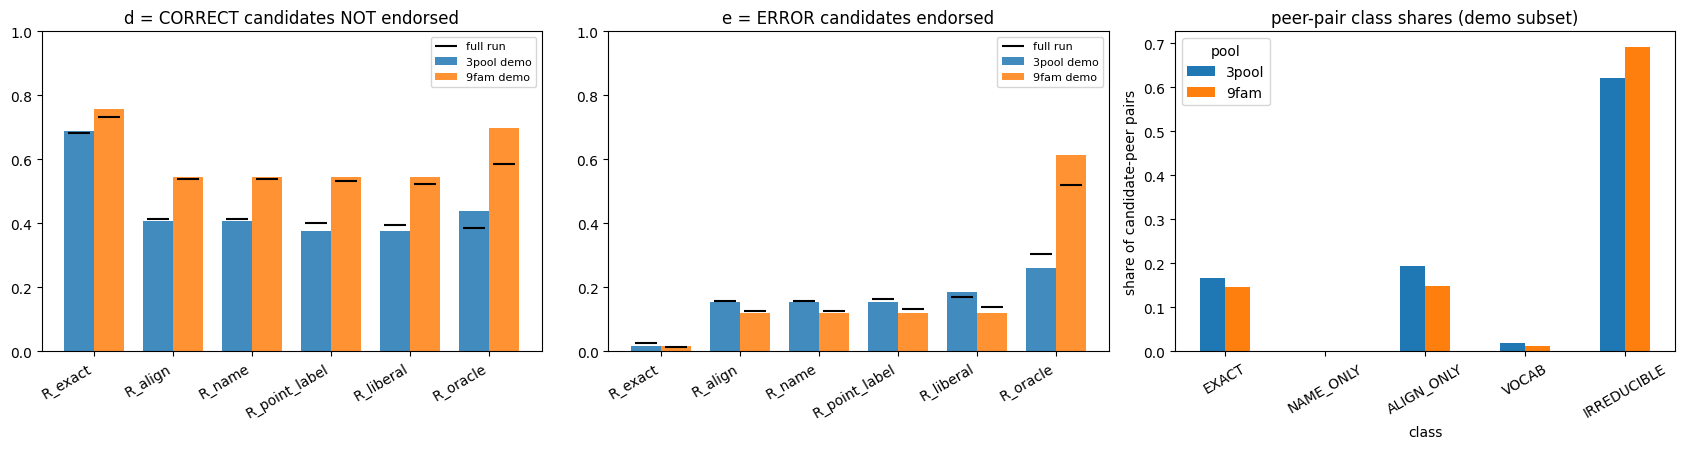

In [13]:
REF = data["reference_metrics_full_run"]
summ = []
for pool in POOLS:
    h = HEADS[pool]
    for rule in RULES:
        summ.append({"pool": pool, "rule": rule,
                     "d_demo": h[rule]["d"], "d_full": REF.get(f"p1_d_{rule}_{pool}"),
                     "e_demo": h[rule]["e"], "e_full": REF.get(f"p1_e_{rule}_{pool}"),
                     "n_cor_demo": h[rule]["n_cor"], "n_err_demo": h[rule]["n_err"]})
S = pd.DataFrame(summ)
print(S.round(3).to_string(index=False))
print()
for k in ("p1_d_floor_pred_3pool", "p1_d_floor_pred_3pool_ci_lo", "p1_d_floor_pred_3pool_ci_hi", "p1_gap_rule_denominator_3pool",
          "p1_specificity_ratio_3pool", "p2_sig_e", "p2_sig_d", "p2_validation_actual_SIG_rate", "p2_validation_calib_err",
          "p3_mde80_L25_250", "p3_n_for_mde_0p069_L25", "audit_n_pass", "audit_n_checks"):
    print(f"full run  {k:<36} {REF[k]:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
x = np.arange(len(RULES))
for ax, metric in zip(axes[:2], ("d", "e")):
    for i, pool in enumerate(POOLS):
        s = S[S.pool == pool]
        ax.bar(x + (i - 0.5) * 0.38, s[f"{metric}_demo"], 0.38, label=f"{pool} demo", alpha=0.85)
        ax.scatter(x + (i - 0.5) * 0.38, s[f"{metric}_full"], color="k", marker="_", s=250, zorder=3,
                   label="full run" if i == 0 else None)
    ax.set_xticks(x, RULES, rotation=30, ha="right")
    ax.set_title({"d": "d = CORRECT candidates NOT endorsed", "e": "e = ERROR candidates endorsed"}[metric])
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
piv = SH.pivot(index="class", columns="pool", values="share").loc[CLS]
piv.plot.bar(ax=axes[2], rot=30)
axes[2].set_title("peer-pair class shares (demo subset)")
axes[2].set_ylabel("share of candidate-peer pairs")
plt.tight_layout()
plt.show()